In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [25]:
df = pd.read_csv("datos_resultados_modularizado/prev_concatenado.csv")

In [27]:
df = pd.read_csv("datos_resultados_modularizado/master_hdbscan_v0_quan.csv")
df = df.sort_values(by=['source_id','ConteoAgrupaciones'], ascending=[False,False]).drop_duplicates(subset=['source_id'], keep='first')
df['probabilidad'] = df['ConteoAgrupaciones']/(df['iteraciones']*9)
df = df.dropna(subset=['probabilidad'])

# Crear bins de probabilidad
bins = np.arange(0, 1.1, 0.1)
df["prob_bin"] = pd.cut(df["probabilidad"], bins, right=False)

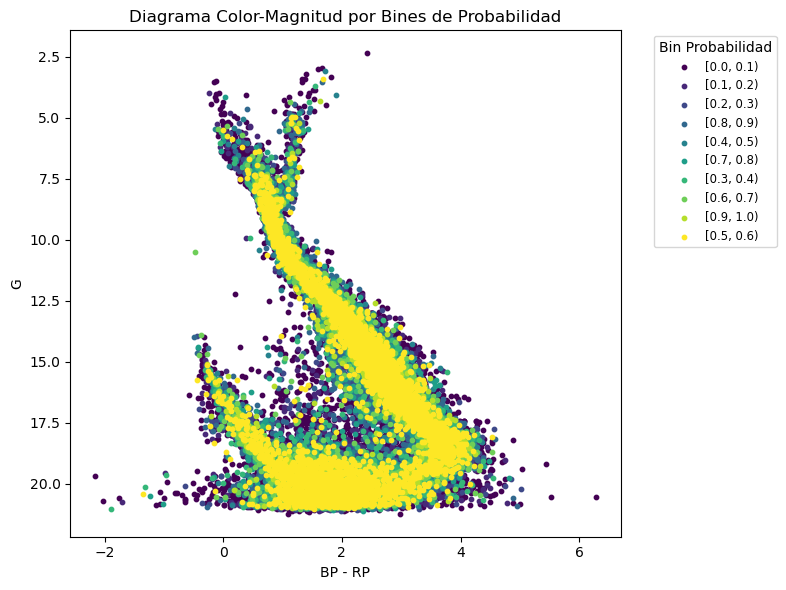

In [28]:
# Crear un mapa de colores para los bins
unique_bins = df["prob_bin"].unique()
colors = plt.cm.viridis(np.linspace(0, 1, len(unique_bins)))
bin_color_map = dict(zip(unique_bins, colors))

# Graficar
plt.figure(figsize=(8, 6))
for bin_cat, color in bin_color_map.items():
    
    subset = df[df["prob_bin"] == bin_cat]
    plt.scatter(subset["bp_rp"], subset["phot_g_mean_mag"], color=color, label=str(bin_cat), s=10)

# Invertir eje Y para magnitudes astronómicas
plt.gca().invert_yaxis()

plt.xlabel("BP - RP")
plt.ylabel("G")
plt.title("Diagrama Color-Magnitud por Bines de Probabilidad")
plt.legend(title="Bin Probabilidad", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.tight_layout()
plt.show()

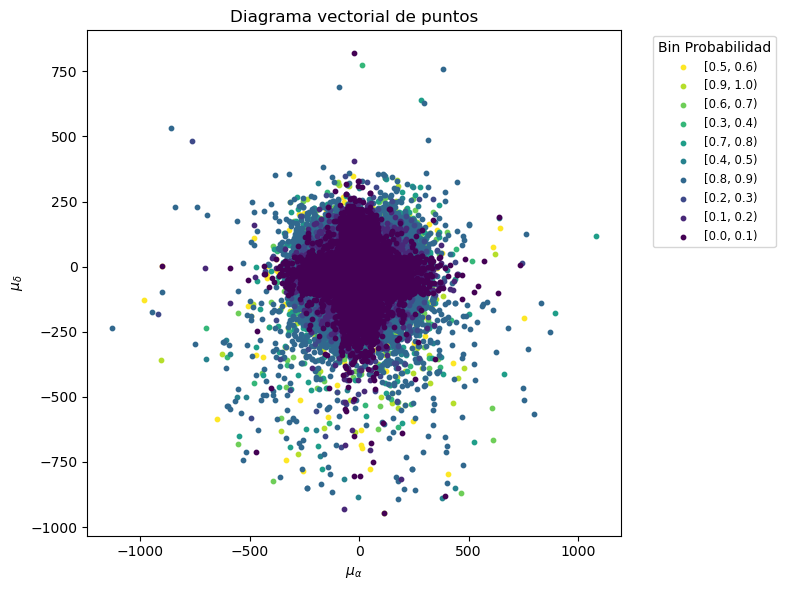

In [29]:
# Graficar
plt.figure(figsize=(8, 6))
for bin_cat, color in reversed(list(bin_color_map.items())):
    subset = df[df["prob_bin"] == bin_cat]
    plt.scatter(subset["pmra"], subset["pmdec"], color=color, label=str(bin_cat), s=10)

# Invertir eje Y para magnitudes astronómicas

plt.xlabel(r"$\mu_{\alpha}$")
plt.ylabel(r"$\mu_{\delta}$")
plt.title("Diagrama vectorial de puntos")
plt.legend(title="Bin Probabilidad", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.tight_layout()
plt.show()

In [30]:
# Graficar
plt.figure(figsize=(8, 6))
for bin_cat, color in reversed(list(bin_color_map.items()))::
    subset = df[df["prob_bin"] == bin_cat]
    plt.scatter(subset["ra"], subset["dec"], color=color, label=str(bin_cat), s=10)

# Invertir eje Y para magnitudes astronómicas

plt.xlabel(r"$\alpha$")
plt.ylabel(r"$\delta$")
plt.title("Diagrama coordenadas")
plt.legend(title="Bin Probabilidad", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.tight_layout()
plt.show()

SyntaxError: invalid syntax (3931494379.py, line 3)

In [ ]:
df['parallax'].describe()